In [1]:
from rdkit import Chem

In [2]:
m = Chem. MolFromSmiles('Cc1ccccc1')

In [ ]:
from rdkit.Chem import Draw

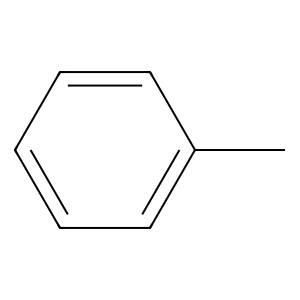

In [10]:
img = Draw.MolToImage(m)
img

In [14]:
import gzip
from rdkit import Chem

# ==========================================
# 🛠️ 步骤 1：写入时用 'wt' (文本模式)
# ==========================================
smiles_seeds = ['CCO', 'Cc1ccccc1', 'O']
mols_pool = [Chem.MolFromSmiles(s) for s in smiles_seeds]

with gzip.open('kitten_test.sdf.gz', 'wt') as f:
    with Chem.SDWriter(f) as writer:
        for m in mols_pool:
            if m is not None:  # 彻底消灭！！！🎯
                writer.write(m)

print("🎉 临时测试包 'kitten_test.sdf.gz' 真正成功无损生成！\n")


# ==========================================
# 🚂 步骤 2：读取时用 'rb' (二进制模式)
# ==========================================
print("====== 🎬 阅兵仪式正式开始 ======")

with gzip.open('kitten_test.sdf.gz', 'rb') as inf:  # 👈 只有这里改成 'rb'！
    with Chem.ForwardSDMolSupplier(inf) as suppl:
        
        for idx, mol in enumerate(suppl):
            if mol is not None:
                print(f"✨ 报告长官！第 {idx} 号化合物正流过流水线，原子数：{mol.GetNumAtoms()}")
            
            if idx == 1:
                print("\n💥 狐狸悄悄拉动了倒带拉杆...")
                try:
                    first_mol = suppl[0] 
                except TypeError as error:
                    print(f"❌ 警告！系统无情拦截并报错：【{error}】")
                    print("（完美！单向通航，无法倒带！）\n")

print("====== 🏁 仪式结束，无菌舱安全 ======")

🎉 临时测试包 'kitten_test.sdf.gz' 真正成功无损生成！

====== 🎬 阅兵仪式正式开始 ======
✨ 报告长官！第 0 号化合物正流过流水线，原子数：3
✨ 报告长官！第 1 号化合物正流过流水线，原子数：7

💥 狐狸悄悄拉动了倒带拉杆...
❌ 警告！系统无情拦截并报错：【'ForwardSDMolSupplier' object is not subscriptable】
（完美！单向通航，无法倒带！）

✨ 报告长官！第 2 号化合物正流过流水线，原子数：1
====== 🏁 仪式结束，无菌舱安全 ======


In [1]:
#完整范例
import os
from rdkit import Chem
from rdkit.Chem import Draw

# ==========================================
# 🛰️ STAGE 1：批量捕捞与体检（Reading & Checking）
# ==========================================
# 准备一个包含正常分子和画错分子的原始列表
raw_smiles = [
    'CCO',                  # 乙醇 (大宝贝 1)
    'Cc1ccccc1',            # 甲苯 (大宝贝 2)
    'C1=CC=CN=C1',          # 吡啶 (大宝贝 3)
    'CO(C)C_INVALID_BOOM'  # 故意混进来的炸弹分子 (毒苹果)
]

mols_vault = []  # 小猫的完美分子无菌舱

print("====== 🎣 开启分子深海捕捞 ======")
for smi in raw_smiles:
    mol = Chem.MolFromSmiles(smi)
    
    # 彻底粉碎 not not None 后的硬核保命检查！
    if mol is None:
        print(f"❌ 警报！抓到一颗毒苹果：'{smi}'！系统已将其无情拦截！")
        continue  # 跳过它，拒绝代码崩溃！
        
    print(f"✅ 成功捕捞：{Chem.MolToSmiles(mol)}，原子数：{mol.GetNumAtoms()}")
    mols_vault.append(mol)

print(f"\n🐳 报告长官，共有 {len(mols_vault)} 个优质分子成功入舱！\n")


# ==========================================
# 🎨 STAGE 2：高清证件照直出（Drawing）
# ==========================================
print("====== 🎨 启动分子视觉魔法 ======")

# 抓出第 1 号分子（甲苯）来一张直观的特写照
star_mol = mols_vault[1] 
output_image_path = 'toluene_profile.png'

# 施展一次性画图法术
Draw.MolToFile(star_mol, output_image_path)

print(f"📸 咔嚓！甲苯分子的 2D 证件照已绝赞输出到：'{output_image_path}'！")
print("（快去你的文件夹里双击打开它，超级治愈！）\n")


# ==========================================
# 💾 STAGE 3：无菌舱终极封存（Writing）
# ==========================================
print("====== 💾 启动批量打包封存 ======")
output_sdf_path = 'kitten_perfect_collection.sdf'

# 召唤高级翻译机器人（类），强行与输出路径绑定，使用 with 契约安全锁
with Chem.SDWriter(output_sdf_path) as writer:
    for m in mols_vault:
        writer.write(m)  # 喂食分子，机器人自动在后台喷射标准坐标文本

print(f"🎉 封存任务圆满落幕！所有合规分子已整齐码入：'{output_sdf_path}'！")
print("（Mission completely accomplished! 🪐）")

====== 🎣 开启分子深海捕捞 ======
✅ 成功捕捞：CCO，原子数：3
✅ 成功捕捞：Cc1ccccc1，原子数：7
✅ 成功捕捞：c1ccncc1，原子数：6
❌ 警报！抓到一颗毒苹果：'CO(C)C_INVALID_BOOM'！系统已将其无情拦截！

🐳 报告长官，共有 3 个优质分子成功入舱！

====== 🎨 启动分子视觉魔法 ======
📸 咔嚓！甲苯分子的 2D 证件照已绝赞输出到：'toluene_profile.png'！
（快去你的文件夹里双击打开它，超级治愈！）

====== 💾 启动批量打包封存 ======
🎉 封存任务圆满落幕！所有合规分子已整齐码入：'kitten_perfect_collection.sdf'！
（Mission completely accomplished! 🪐）


[12:31:55] SMILES Parse Error: syntax error while parsing: CO(C)C_INVALID_BOOM
[12:31:55] SMILES Parse Error: check for mistakes around position 7:
[12:31:55] CO(C)C_INVALID_BOOM
[12:31:55] ~~~~~~^
[12:31:55] SMILES Parse Error: Failed parsing SMILES 'CO(C)C_INVALID_BOOM' for input: 'CO(C)C_INVALID_BOOM'


一共有2个分子入选
一共有2个分子入选
发现Lumi藏的炸弹


[13:02:55] SMILES Parse Error: syntax error while parsing: C(O)(C)(C)C_BOOM
[13:02:55] SMILES Parse Error: check for mistakes around position 12:
[13:02:55] C(O)(C)(C)C_BOOM
[13:02:55] ~~~~~~~~~~~^
[13:02:55] SMILES Parse Error: Failed parsing SMILES 'C(O)(C)(C)C_BOOM' for input: 'C(O)(C)(C)C_BOOM'
[13:02:55] SMILES Parse Error: syntax error while parsing: C(O)(C)(C)C_BOOM
[13:02:55] SMILES Parse Error: check for mistakes around position 12:
[13:02:55] C(O)(C)(C)C_BOOM
[13:02:55] ~~~~~~~~~~~^
[13:02:55] SMILES Parse Error: Failed parsing SMILES 'C(O)(C)(C)C_BOOM' for input: 'C(O)(C)(C)C_BOOM'


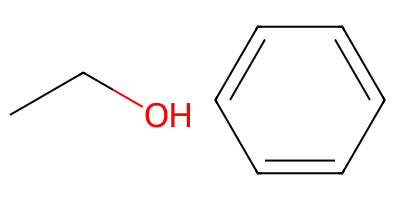

In [8]:
#练习1
import os
from rdkit import Chem
from rdkit.Chem import Draw
smiles_list = ['CCO', 'c1ccccc1', 'C(O)(C)(C)C_BOOM']
mols = [Chem.MolFromSmiles(s) for s in smiles_list]
healthy_mols = [Chem.MolFromSmiles(hm) for hm in smiles_list if Chem.MolFromSmiles(hm) is not None]
for m in mols:
    if m is None:
        print('发现Lumi藏的炸弹')
        continue
    print(f'一共有{len(healthy_mols)}个分子入选')
grid_img = Draw.MolsToGridImage(healthy_mols, molsPerRow = 2) #GridImage可以一次输出多个分子的图像
grid_img


In [ ]:
#练习2
good_mols = ['假装这里有五个分子']
moles = [Chem.MolFromSmiles(m) for m in good_mols]
with open('stage1_output.sdf', 'wt') as f:
    with Chem.SDWriter(f) as mol_writer:
        for m in moles:
            if m is None:
                print('错误')
                continue
            mol_writer.write(m)
        


In [ ]:
#请写一段小巧的 for 循环，遍历这个分子里的所有原子，并且只打印出
# 里面所有“不是碳元素（也就是符号不等于 'C'）”的原子符号！
m = Chem.MolFromSmiles('C1OC1') # 环氧乙烷
for atom in m.GetAtoms() :
    if atom.GetSymbol() != 'C':
        print (atom.GetSymbol())


O


In [22]:
m = Chem.MolFromSmiles('C1OC1')
oxygen_neighbors = [on.GetSymbol() for on in m.GetAtomWithIdx(1).GetNeighbors()]
print(oxygen_neighbors)


['C', 'C']


In [ ]:
mega_mol = "一个超级复杂的骨架"
ri = mega_mol.GetRingInfo()
#查询编号5的原子到底存在于哪些环里
print(ri.NumAtomRings(5))

In [ ]:
m = Chem.MolFromSmiles('CCO')
#抓取0号键
bond_0 = m.GetBondWithIdx(0)
mole_begin_end = [bond_0.GetBeginAtom(), bond_0.GetEndAtom()]#也可以.GetBeginAtomIdx()
mole_begin_end_name = [mn.GetSymbol() for mn in mole_begin_end]
mole_begin_end_name

['C', 'C']

In [ ]:
mystery_mol = "一个带有特殊三元环的复杂分子组合"
#如果发现有原子身处 3 元环里，就打印出这个原子的索引编号（Idx）
for atoms in mystery_mol.GetAtoms():
    if atoms.IsInRing(3) == True:
        print(atoms.GetIdx())

AttributeError: 'str' object has no attribute 'GetAtoms'

In [33]:
m = Chem.MolFromSmiles('CCN')
atom = m.GetAtomWithIdx(2) # 抓到氮原子
print(atom.GetSymbol())

N


In [ ]:
from rdkit import Chem
from rdkit.Chem import AllChem

# 召唤一个稍微有点复杂的稠环分子
m = Chem.MolFromSmiles('c1nccc2n1ccc2')

# ⚡️ 呼叫平面设计师！帮它计算出一套最漂亮的二维排版坐标
AllChem.Compute2DCoords(m)
# 屏幕上会啪叽吐出一个数字：0 （在 C++ 的世界里，0 代表一切顺利，没有任何报错！）

0

In [35]:
# 1. 先定义好你的核心骨架（母体母模板）
template = Chem.MolFromSmiles('c1nccc2n1ccc2')
AllChem.Compute2DCoords(template) # 把它先画漂亮

# 2. 准备一堆在这个骨架上乱长了各种不同侧链的女儿分子
ms = [Chem.MolFromSmiles(smi) for smi in ('OCCc1ccn2cnccc12', 'C1CC1Oc1cc2ccncn2c1', 'CNC(=O)c1nccc2cccn12')]

# 3. 开启“无情模仿”循环！
for m in ms:
    # 🌟 让女儿分子强行照着母体的二维姿势去排版
    AllChem.GenerateDepictionMatching2DStructure(m, template)

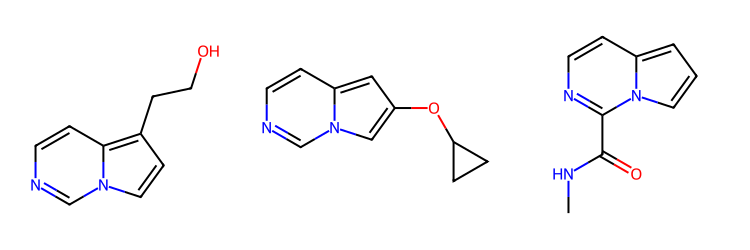

In [41]:
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import Draw

# 1. 制造妈妈骨架，并算好它的 2D 座位表
template = Chem.MolFromSmiles('c1nccc2n1ccc2')
AllChem.Compute2DCoords(template)

# 2. 制造 3 个长了不同侧链的女儿分子
ms = [Chem.MolFromSmiles(smi) for smi in ('OCCc1ccn2cnccc12', 'C1CC1Oc1cc2ccncn2c1', 'CNC(=O)c1nccc2cccn12')]

# 3. 施展列队对齐手术！
for m in ms:
    AllChem.GenerateDepictionMatching2DStructure(m, template)

# 🌟 核心：加上这句大招，把它们画出来！
grid_img = Draw.MolsToGridImage(ms, molsPerRow=3, subImgSize=(250, 250))

# 亮相吧宝贝们！
grid_img

In [42]:
from rdkit import Chem
from rdkit.Chem import AllChem

# 找来一个扁平的环丁烷
m = Chem.MolFromSmiles('C1CCC1OC')

# 1️⃣ 穿上外套：必须先加氢！(3D 模拟的绝对死理)
m2 = Chem.AddHs(m)

# 2️⃣ 注入灵魂：强行把分子嵌入到 3D 空间里
AllChem.EmbedMolecule(m2)
# 屏幕上又会无声地吐出一个：0 （代表 3D 骨架搭建完美成功！）

0

In [43]:
!pip install py3Dmol

In [ ]:
import py3Dmol
from rdkit.Chem import AllChem
m = Chem.MolFromSmiles('CCO')
m2 = Chem.AddHs(m)
AllChem.EmbedMolecule(m2)
AllChem.MMFFOptimizeMolecule(m2)
mol_block = Chem.MolToMolBlock(m2) #要画3d图必须把信息转换成molBlock表
# B. 创建一个全息投影窗口（Viewer），给它安排一个 400x400 的size
p_viewer = py3Dmol.view(width=400,height=400)
# C. 把刚刚翻译好的坐标大表塞进投影仪里，并告诉它它是 sdf/mol 格式
p_viewer.addModel(mol_block,'mol')
# D. 设置投影风格：
# 'stick'（棍状图，看原子和键）、'sphere'（球充填图，看体积）、'cartoon'（看蛋白二级结构）
p_viewer.setStyle({'stick': {}}) #此处的{}内可以填修改视觉效果的参数 eg：{'stick': {'opacity': 0.5}}
# E. 调整视角，让分子自动占据整个画面
p_viewer.zoomTo()
#p_viewer.spin() #旋转
p_viewer.show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.